In [4]:
import pulp
print(pulp.__version__)

2.9.0


In [5]:
from pulp import *

# створюємо задачу — мінімізація
prob = LpProblem("simple_example", LpMinimize)

# змінні рішення
x = LpVariable("x", lowBound=0)
y = LpVariable("y", lowBound=0)

# цільова функція
prob += 3*x + 2*y

# обмеження
prob += x + y >= 4
prob += x + 3*y >= 6

# розв'язати
prob.solve(PULP_CBC_CMD(msg=0))

print(f"Статус: {LpStatus[prob.status]}")
print(f"x = {value(x)}")
print(f"y = {value(y)}")
print(f"Мінімум = {value(prob.objective)}")

Статус: Optimal
x = 0.0
y = 4.0
Мінімум = 8.0


In [8]:
from pulp import listSolvers
print(listSolvers(onlyAvailable=True))

['PULP_CBC_CMD']


In [11]:
from pulp import *
import numpy as np

# ── Параметри батареї ──────────────────────────────────────────
S_max  = 10.0   # ємність, кВт·год
P_max  = 5.0    # макс потужність, кВт
eta    = 0.95   # КПД
S_init = 5.0    # початковий заряд (50%)
T      = 24

# ── Дані на один день ──────────────────────────────────────────
# Ціни: береш один рядок з prices_be_hourly.csv
# Поки — синтетика (типовий профіль Бельгії, EUR/kWh)
prices = np.array([
    0.08, 0.07, 0.06, 0.06, 0.07, 0.09,
    0.13, 0.18, 0.20, 0.17, 0.15, 0.14,
    0.13, 0.14, 0.15, 0.17, 0.21, 0.25,
    0.23, 0.20, 0.17, 0.14, 0.11, 0.09
])

# Споживання: синтетичний профіль домогосподарства (кВт·год/год)
load = np.array([
    0.3, 0.2, 0.2, 0.2, 0.3, 0.5,
    0.8, 1.0, 0.7, 0.5, 0.4, 0.5,
    0.6, 0.5, 0.4, 0.5, 0.9, 1.2,
    1.1, 0.9, 0.7, 0.6, 0.4, 0.3
])

# ── LP задача ──────────────────────────────────────────────────
def optimize_day(prices, load, S_max, P_max, eta, S_init, cyclic=True):
    prob = LpProblem("battery_day", LpMinimize)

    c = [LpVariable(f"c_{t}", lowBound=0, upBound=P_max) for t in range(T)]
    d = [LpVariable(f"d_{t}", lowBound=0, upBound=P_max) for t in range(T)]
    s = [LpVariable(f"s_{t}", lowBound=0, upBound=S_max) for t in range(T)]

    # Цільова функція
    prob += lpSum(prices[t] * (load[t] + c[t] - d[t]) for t in range(T))

    # Баланс енергії
    prob += s[0] == S_init + eta * c[0] - d[0]
    for t in range(1, T):
        prob += s[t] == s[t-1] + eta * c[t] - d[t]

    # Не продаємо в мережу
    for t in range(T):
        prob += d[t] <= load[t]

    # щоб не використовувати первинний заряд "як безкоштовний"   
    if cyclic:
        prob += s[T-1] >= S_init

    prob.solve(PULP_CBC_CMD(msg=0))

    return {
        "status":    LpStatus[prob.status],
        "cost":      value(prob.objective),
        "c":         [value(c[t]) for t in range(T)],
        "d":         [value(d[t]) for t in range(T)],
        "s":         [value(s[t]) for t in range(T)],
        "s_final":   value(s[T-1])   # для ланцюжка між днями
    }

# ── Запуск ────────────────────────────────────────────────────
result = optimize_day(prices, load, S_max, P_max, eta, S_init, cyclic=True)

cost_no_battery = sum(prices[t] * load[t] for t in range(T))

print(f"Статус:              {result['status']}")
print(f"Витрати без батареї: {cost_no_battery:.4f} EUR")
print(f"Витрати з батареєю:  {result['cost']:.4f} EUR")
print(f"Економія за день:    {cost_no_battery - result['cost']:.4f} EUR")
print(f"Залишок заряду:      {result['s_final']:.2f} кВт·год")

Статус:              Optimal
Витрати без батареї: 2.2560 EUR
Витрати з батареєю:  1.1563 EUR
Економія за день:    1.0997 EUR
Залишок заряду:      5.00 кВт·год


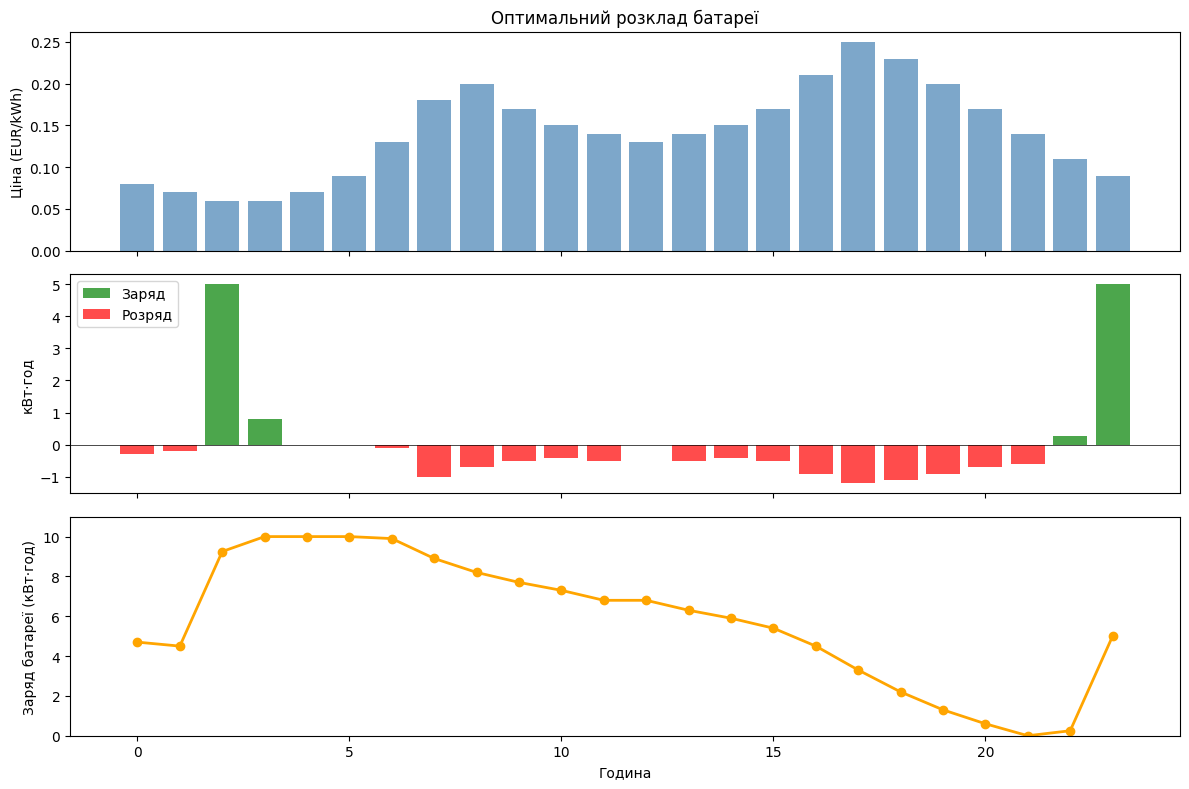

In [12]:
import matplotlib.pyplot as plt

hours = list(range(24))
c_val = result["c"]
d_val = result["d"]
s_val = result["s"]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Ціни
ax1.bar(hours, prices, color="steelblue", alpha=0.7)
ax1.set_ylabel("Ціна (EUR/kWh)")
ax1.set_title("Оптимальний розклад батареї")

# Заряд / розряд
ax2.bar(hours, c_val, color="green", alpha=0.7, label="Заряд")
ax2.bar(hours, [-x for x in d_val], color="red", alpha=0.7, label="Розряд")
ax2.set_ylabel("кВт·год")
ax2.legend()
ax2.axhline(0, color="black", linewidth=0.5)

# Стан заряду
ax3.plot(hours, s_val, color="orange", linewidth=2, marker="o")
ax3.set_ylabel("Заряд батареї (кВт·год)")
ax3.set_xlabel("Година")
ax3.set_ylim(0, S_max + 1)

plt.tight_layout()
plt.show()

In [ ]:
def threshold_strategy(prices, load, S_max, P_max, eta, S_init):
    threshold = np.mean(prices)  # середня ціна як поріг
    
    s = S_init
    total_cost = 0
    c_val, d_val, s_val = [], [], []
    
    for t in range(T):
        if prices[t] < threshold:
            # Дешева година — заряджаємо
            charge = min(P_max, S_max - s)  # не більше ніж вільне місце
            discharge = 0
        else:
            # Дорога година — розряджаємо
            charge = 0
            discharge = min(P_max, s, load[t])  # не більше ніж є в батареї і споживання
        
        s = s + eta * charge - discharge
        total_cost += prices[t] * (load[t] + charge - discharge)
        
        c_val.append(charge)
        d_val.append(discharge)
        s_val.append(s)
    
    return {
        "cost": total_cost,
        "c": c_val,
        "d": d_val,
        "s": s_val,
        "s_final": s
    }

# ── Порівняння трьох підходів ──────────────────────────────────
# cost_fixed      = sum(np.mean(prices) * load[t] for t in range(T))  # заряд при фіксованій ціні як середнє всіх цін
cost_no_battery = sum(prices[t] * load[t] for t in range(T))         # динамічний, без батареї
result_lp       = optimize_day(prices, load, S_max, P_max, eta, S_init, cyclic=True)
result_rule     = threshold_strategy(prices, load, S_max, P_max, eta, S_init)

print(f"Фіксований тариф (без батареї): {cost_fixed:.4f} EUR")
print(f"Динамічний (без батареї):        {cost_no_battery:.4f} EUR")
print(f"Просте правило (поріг):          {result_rule['cost']:.4f} EUR")
print(f"LP оптимізація:                  {result_lp['cost']:.4f} EUR")
print()
print(f"Економія LP vs без батареї:      {cost_no_battery - result_lp['cost']:.4f} EUR")
print(f"Економія правило vs без батареї: {cost_no_battery - result_rule['cost']:.4f} EUR")
print(f"LP краще за правило на:          {result_rule['cost'] - result_lp['cost']:.4f} EUR")

Фіксований тариф (без батареї): 1.9351 EUR
Динамічний (без батареї):        2.2560 EUR
Просте правило (поріг):          2.2139 EUR
LP оптимізація:                  1.1563 EUR

Економія LP vs без батареї:      1.0997 EUR
Економія правило vs без батареї: 0.0421 EUR
LP краще за правило на:          1.0576 EUR


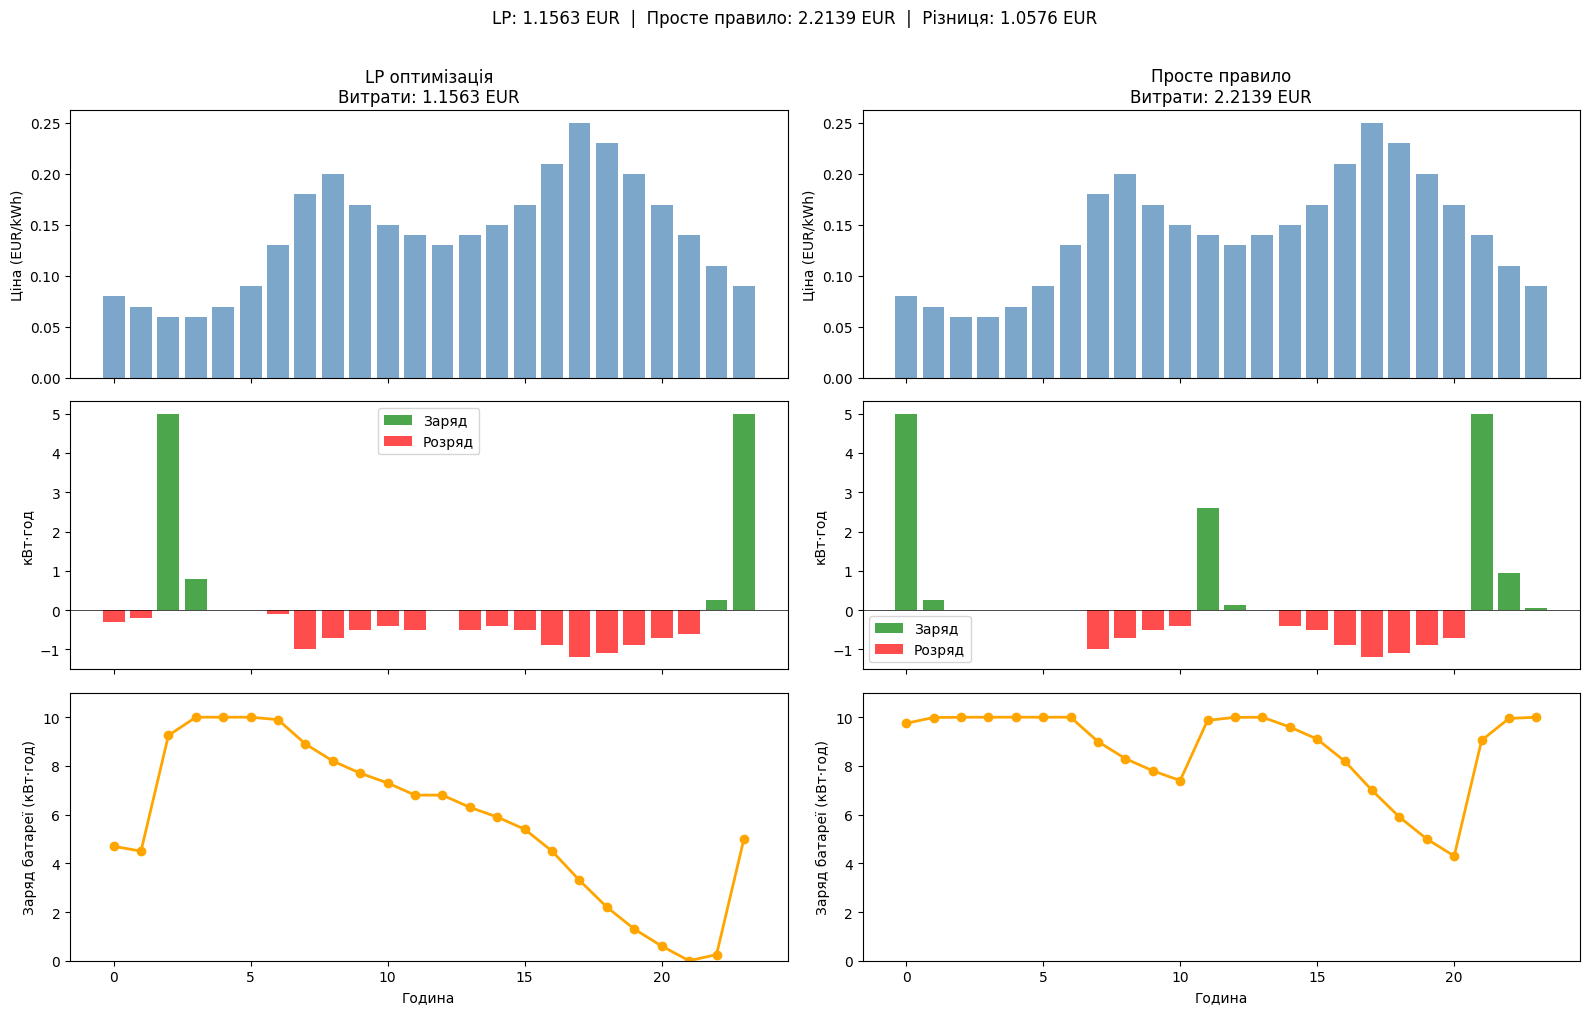

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)

hours = list(range(24))

for col, (res, title) in enumerate([(result_lp, "LP оптимізація"), (result_rule, "Просте правило")]):
    
    # Ціни
    axes[0, col].bar(hours, prices, color="steelblue", alpha=0.7)
    axes[0, col].set_ylabel("Ціна (EUR/kWh)")
    axes[0, col].set_title(f"{title}\nВитрати: {res['cost']:.4f} EUR")

    # Заряд / розряд
    axes[1, col].bar(hours, res["c"], color="green", alpha=0.7, label="Заряд")
    axes[1, col].bar(hours, [-x for x in res["d"]], color="red", alpha=0.7, label="Розряд")
    axes[1, col].axhline(0, color="black", linewidth=0.5)
    axes[1, col].set_ylabel("кВт·год")
    axes[1, col].legend()

    # Стан заряду
    axes[2, col].plot(hours, res["s"], color="orange", linewidth=2, marker="o")
    axes[2, col].set_ylabel("Заряд батареї (кВт·год)")
    axes[2, col].set_xlabel("Година")
    axes[2, col].set_ylim(0, S_max + 1)

plt.suptitle(
    f"LP: {result_lp['cost']:.4f} EUR  |  Просте правило: {result_rule['cost']:.4f} EUR  |  "
    f"Різниця: {result_rule['cost'] - result_lp['cost']:.4f} EUR",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()